In [1]:
# Importing required data manipulation libraries
import pandas as pd
import numpy as np

In [2]:
df=pd.read_excel(r"C:\Users\Akshay Birare\PycharmProjects\Assignments\Assignment Data Sources\Decision Tree\heart_disease.xlsx", sheet_name = 'Heart_disease')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,reversable defect,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,normal,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,fixed defect,4


In [3]:
#EDA
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [4]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


<Axes: >

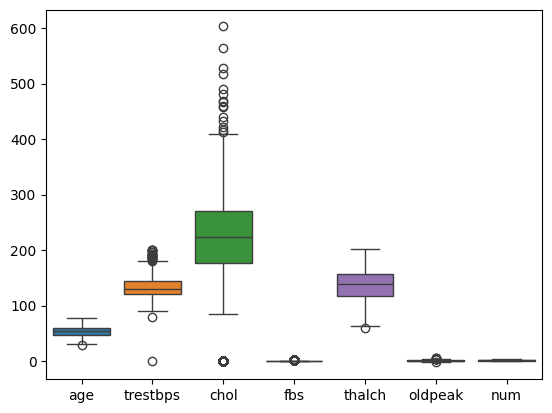

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(data=df)

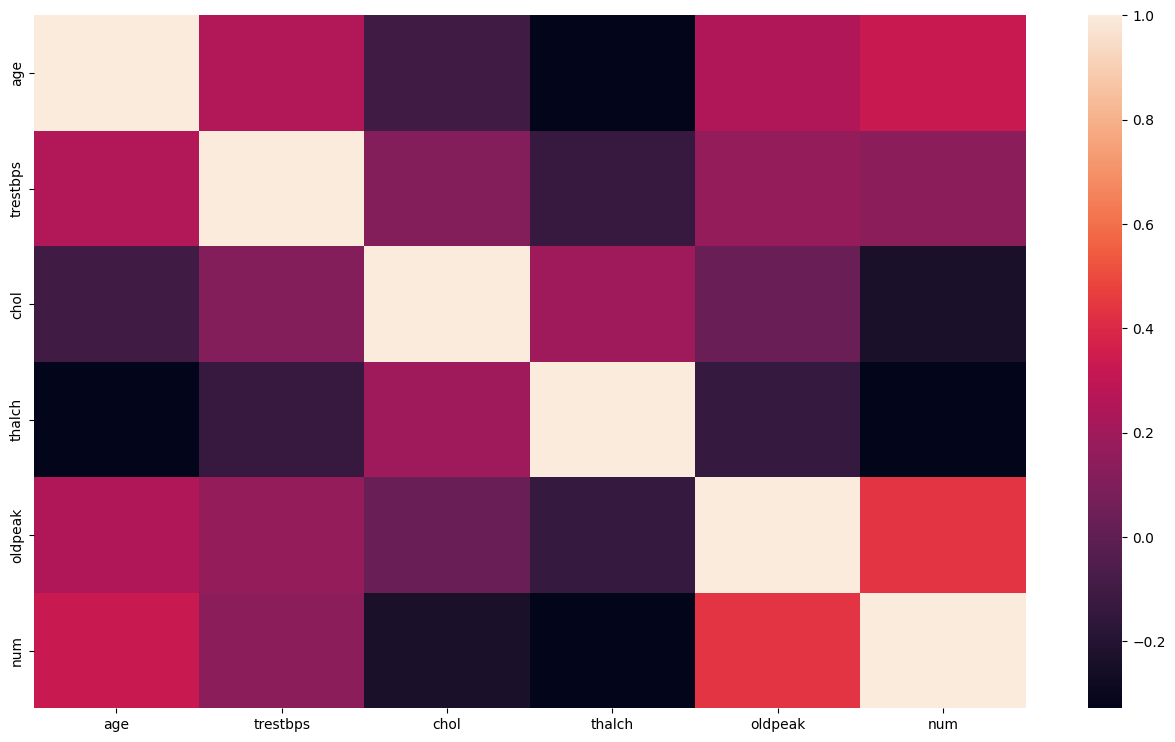

In [6]:
numerical_columns= df.select_dtypes(include=['number'])
df_mat=numerical_columns.corr()
plt.figure (figsize = (16,9))
sns.heatmap(df_mat)
plt.show()

In [7]:
#feature engineering
#encoding categorical variable
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
categorical_columns= df.select_dtypes(include=['object', 'bool'])
categorical_columns

,sex,cp,fbs,restecg,exang,slope,thal
0,Male,typical angina,True,lv hypertrophy,False,downsloping,fixed defect
1,Male,atypical angina,False,normal,False,flat,fixed defect
2,Male,asymptomatic,False,normal,False,flat,fixed defect
3,Male,typical angina,False,lv hypertrophy,False,flat,fixed defect
4,Male,asymptomatic,False,normal,True,flat,fixed defect
...,...,...,...,...,...,...,...
903,Male,asymptomatic,False,normal,False,upsloping,reversable defect
904,Male,asymptomatic,False,st-t abnormality,True,flat,reversable defect
905,Male,non-anginal,False,lv hypertrophy,True,downsloping,normal
906,Male,non-anginal,True,st-t abnormality,TURE,downsloping,fixed defect


In [8]:
categorical_columns.dtypes

sex        object
cp         object
fbs          bool
restecg    object
exang      object
slope      object
thal       object
dtype: object

In [9]:
# Convert Boolean values to string
df['exang'] = df['exang'].astype(str)

In [10]:
# Define a function to clean and standardize values
def clean_boolean(value):
    value = value.lower()  # Convert to lowercase
    return 'true' if value.startswith('t') else 'false'  # Standardize values

# Apply the function to the 'Category' column
df['exang'] = df['exang'].apply(clean_boolean)

print(df)

     age   sex               cp  trestbps  chol    fbs           restecg  \
0     63  Male   typical angina       145   233   True    lv hypertrophy   
1     41  Male  atypical angina       135   203  False            normal   
2     57  Male     asymptomatic       140   192  False            normal   
3     52  Male   typical angina       118   186  False    lv hypertrophy   
4     57  Male     asymptomatic       110   201  False            normal   
..   ...   ...              ...       ...   ...    ...               ...   
903   53  Male     asymptomatic       125     0  False            normal   
904   62  Male     asymptomatic       166   170  False  st-t abnormality   
905   56  Male      non-anginal       170     0  False    lv hypertrophy   
906   56  Male      non-anginal       144   208   True  st-t abnormality   
907   57  Male     asymptomatic       142   277   True  st-t abnormality   

     thalch  exang  oldpeak        slope               thal  num  
0       150  false  

In [11]:
# df['sex']=label_encoder.fit_transform(df['sex'])
# df['cp']=label_encoder.fit_transform(df['cp'])
# df['fbs']=label_encoder.fit_transform(df['fbs'])
# df['restecg']=label_encoder.fit_transform(df['restecg'])
# df['exang']=label_encoder.fit_transform(df['exang'])
# df['slope']=label_encoder.fit_transform(df['slope'])
# df['thal']=label_encoder.fit_transform(df['thal'])

# Initialize dictionary to store encoders
label_encoders = {}

# Loop through categorical columns
for col in df.select_dtypes(include=['object']).columns:
    label_encoders[col] = LabelEncoder()  # Create LabelEncoder instance
    df[col] = label_encoders[col].fit_transform(df[col])  # Apply encoding

print(df)

     age  sex  cp  trestbps  chol    fbs  restecg  thalch  exang  oldpeak  \
0     63    1   3       145   233   True        0     150      0      2.3   
1     41    1   1       135   203  False        1     132      0      0.0   
2     57    1   0       140   192  False        1     148      0      0.4   
3     52    1   3       118   186  False        0     190      0      0.0   
4     57    1   0       110   201  False        1     126      1      1.5   
..   ...  ...  ..       ...   ...    ...      ...     ...    ...      ...   
903   53    1   0       125     0  False        1     120      0      1.5   
904   62    1   0       166   170  False        2     120      1      3.0   
905   56    1   2       170     0  False        0     123      1      2.5   
906   56    1   2       144   208   True        2     105      1      NaN   
907   57    1   0       142   277   True        2     182      0      NaN   

     slope  thal  num  
0        0     0    0  
1        1     0    0  
2  

In [12]:
# # Standardizing values: Convert to lowercase and fix typos
# def update_values (value):
#     if str(value).startwith(('T','t')):
#         return "True"
#     elif str(value).startwith(('F','f')):
#         return "False"
#     else:
#         return value

In [13]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,True,0,150,0,2.3,0,0,0
1,41,1,1,135,203,False,1,132,0,0.0,1,0,0
2,57,1,0,140,192,False,1,148,0,0.4,1,0,0
3,52,1,3,118,186,False,0,190,0,0.0,1,0,0
4,57,1,0,110,201,False,1,126,1,1.5,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,1,0,125,0,False,1,120,0,1.5,2,2,4
904,62,1,0,166,170,False,2,120,1,3.0,1,2,4
905,56,1,2,170,0,False,0,123,1,2.5,0,1,4
906,56,1,2,144,208,True,2,105,1,NaN,0,0,4


In [14]:
#scaling the numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['age','trestbps','chol','oldpeak','num']]=scaler.fit_transform(df[['age','trestbps','chol','oldpeak','num']])
df[['age','trestbps','chol','oldpeak','num']]
df


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,1.006027,1,3,0.567394,0.281297,True,0,150,0,1.288612,0,0,-0.881977
1,-1.397560,1,1,0.076967,0.013526,False,1,132,0,-0.815249,1,0,-0.881977
2,0.350503,1,0,0.322181,-0.084656,False,1,148,0,-0.449360,1,0,-0.881977
3,-0.195767,1,3,-0.756760,-0.138211,False,0,190,0,-0.815249,1,0,-0.881977
4,0.350503,1,0,-1.149102,-0.004325,False,1,126,1,0.556834,1,0,-0.881977
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,-0.086513,1,0,-0.413461,-1.798388,False,1,120,0,0.556834,2,2,2.615119
904,0.896773,1,0,1.597292,-0.281021,False,2,120,1,1.928917,1,2,2.615119
905,0.241249,1,2,1.793463,-1.798388,False,0,123,1,1.471556,0,1,2.615119
906,0.241249,1,2,0.518352,0.058155,True,2,105,1,NaN,0,0,2.615119


In [15]:
#decision tree classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [16]:
x=df.drop('sex', axis=1)
y=df['sex']

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [18]:
clf = DecisionTreeClassifier()
clf.fit(x_train, y_train)

DecisionTreeClassifier()

In [19]:
y_pred=clf.predict(x_test)

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6923076923076923
              precision    recall  f1-score   support

           0       0.39      0.37      0.38        46
           1       0.79      0.80      0.80       136

    accuracy                           0.69       182
   macro avg       0.59      0.59      0.59       182
weighted avg       0.69      0.69      0.69       182



In [21]:
#Hyperparameter tunig
from sklearn.model_selection import GridSearchCV
param_grid= {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [22]:
grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)

# Best hyperparameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


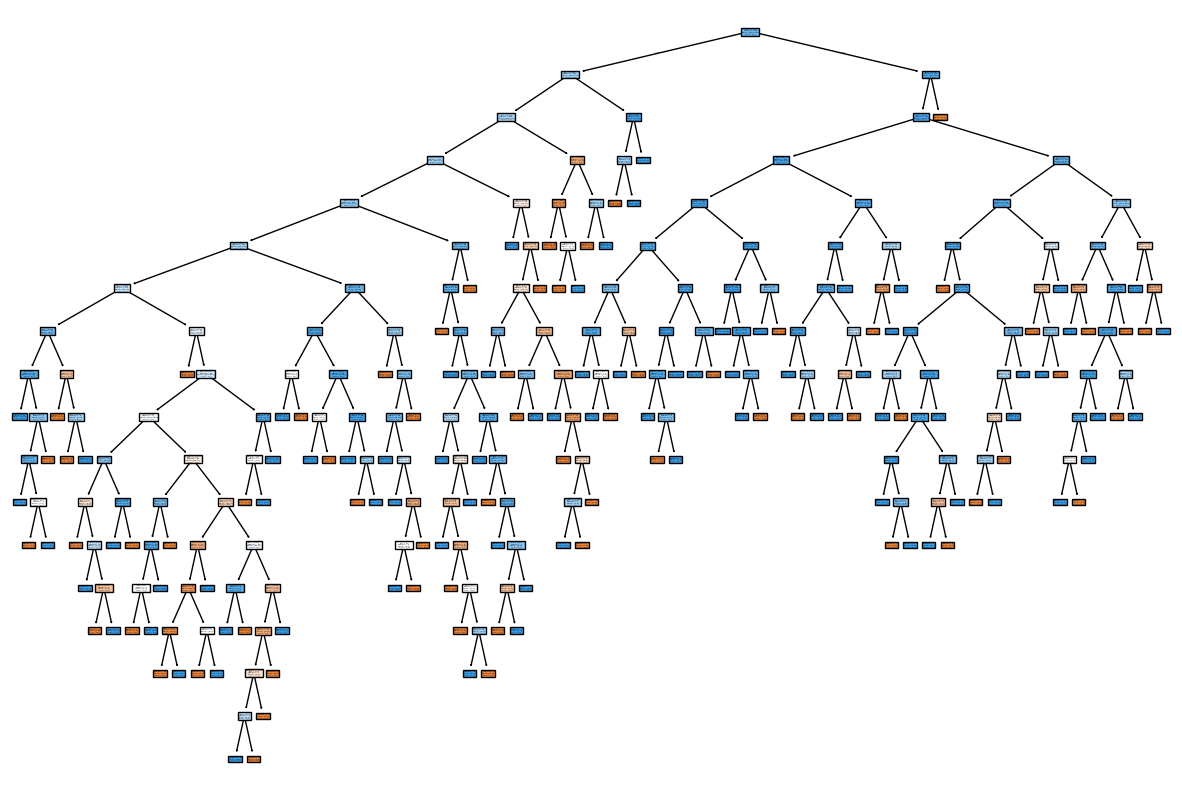

Feature Importances: [0.19483899 0.06731899 0.10230137 0.1607034  0.01452362 0.03710422
 0.14844515 0.03998705 0.10561302 0.01761915 0.00599167 0.10555337]


In [23]:
from sklearn.tree import plot_tree
# Visualize the tree
plt.figure(figsize=(15, 10))
plot_tree(clf, feature_names=x.columns, class_names=True, filled=True)
plt.show()
# Important features
print("Feature Importances:", clf.feature_importances_)

#### Interview questions
##### 1)ans: Common hyper parameters of decision tree models are and their significance in performance are;


Max Depth: This limits the depth of the tree. l to capture important relationships.

Min Samples Split: Determines the minimum number of samples required to split an internal node.

Min Samples Leaf: Specifies the minimum number of samples required to be in a leaf node. 

Max Features: Controls the number of features to consider when looking for the best split.

Criterion: Defines the function used to measure the quality of a split (e.g., Gini impurity or entropy). 


##### 2)ans:
Label Encoding: This technique assigns a unique integer to each category in a categorical variable.

One-Hot Encoding: This creates a binary column for each category, with values of 0 or 1.